In [3]:
import requests
import pandas as pd

# Frankfurter API ile güncel kuru test edelim
response = requests.get("https://api.frankfurter.app/latest?from=USD&to=TRY")
data = response.json()

print("✅ API bağlantısı başarılı!")
print(data)

✅ API bağlantısı başarılı!
{'amount': 1.0, 'base': 'USD', 'date': '2026-06-30', 'rates': {'TRY': 46.66}}


In [4]:
import requests
import pandas as pd

# Son 2 yıllık USD/TRY ve EUR/TRY verisi
url = "https://api.frankfurter.app/2023-07-01..?from=USD&to=TRY,EUR"
response = requests.get(url)
data = response.json()

print("✅ Veri çekildi!")
print(f"Başlangıç: {data['start_date']}")
print(f"Bitiş: {data['end_date']}")
print(f"Toplam gün sayısı: {len(data['rates'])}")

✅ Veri çekildi!
Başlangıç: 2023-06-30
Bitiş: 2026-06-30
Toplam gün sayısı: 765


In [5]:
# JSON verisini DataFrame'e çevirelim
kayitlar = []
for tarih, kurlar in data["rates"].items():
    kayitlar.append({
        "tarih": tarih,
        "USD_TRY": kurlar.get("TRY"),
        "EUR_USD": kurlar.get("EUR")
    })

df = pd.DataFrame(kayitlar)
df["tarih"] = pd.to_datetime(df["tarih"])
df = df.sort_values("tarih").reset_index(drop=True)

# EUR/TRY'yi hesaplayalım (EUR/USD * USD/TRY)
df["EUR_TRY"] = df["EUR_USD"] * df["USD_TRY"]

print(f"✅ DataFrame oluşturuldu! {len(df)} satır")
df.head()

✅ DataFrame oluşturuldu! 765 satır


,tarih,USD_TRY,EUR_USD,EUR_TRY
0,2023-06-30,26.062,0.92030,23.984859
1,2023-07-03,26.078,0.91752,23.927087
2,2023-07-04,26.054,0.91785,23.913664
3,2023-07-05,26.090,0.91920,23.981928
4,2023-07-06,26.015,0.91752,23.869283


✅ Veri kaydedildi! 765 satır


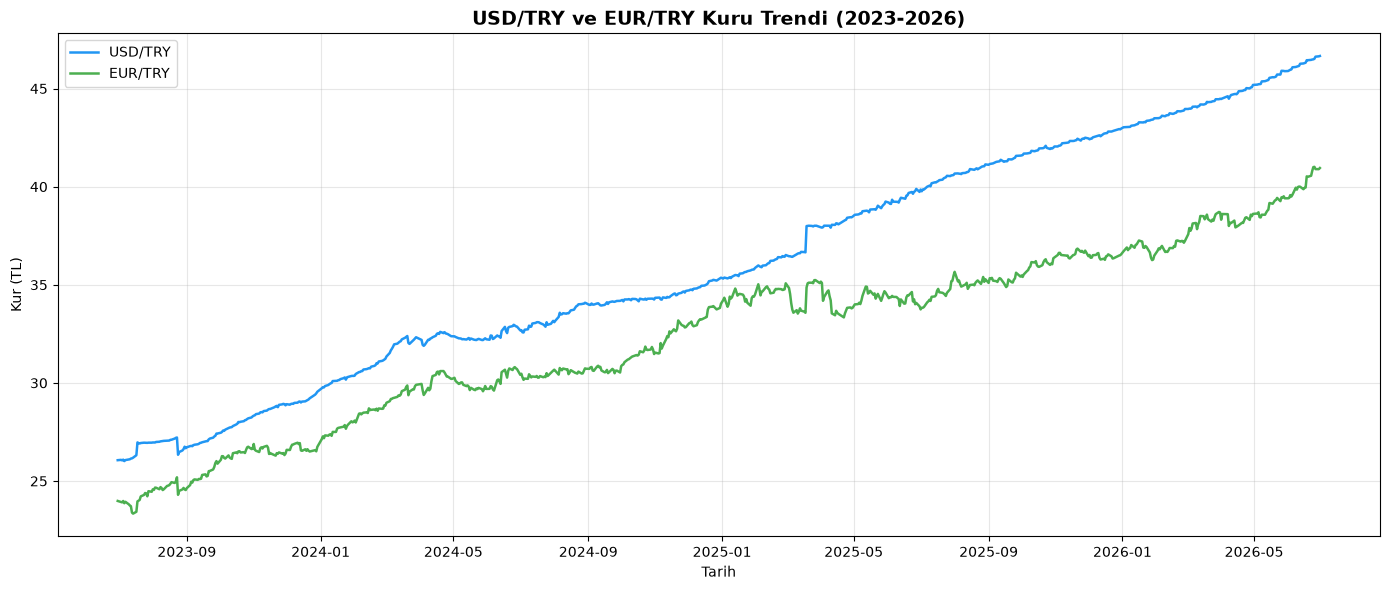

✅ Grafik kaydedildi!


In [6]:
import os
os.makedirs("../data", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)

df.to_csv("../data/doviz_kurlari.csv", index=False, encoding="utf-8-sig")
print(f"✅ Veri kaydedildi! {len(df)} satır")

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (14, 6)

fig, ax = plt.subplots()
ax.plot(df["tarih"], df["USD_TRY"], label="USD/TRY", color="#2196F3", linewidth=1.8)
ax.plot(df["tarih"], df["EUR_TRY"], label="EUR/TRY", color="#4CAF50", linewidth=1.8)

ax.set_title("USD/TRY ve EUR/TRY Kuru Trendi (2023-2026)", fontsize=14, fontweight="bold")
ax.set_xlabel("Tarih")
ax.set_ylabel("Kur (TL)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/01_doviz_trend.png", dpi=150)
plt.show()
print("✅ Grafik kaydedildi!")

In [7]:
# Günlük yüzdesel değişim (getiri)
df["USD_TRY_getiri"] = df["USD_TRY"].pct_change() * 100

# 30 günlük hareketli ortalama
df["USD_TRY_MA30"] = df["USD_TRY"].rolling(window=30).mean()

# Temel istatistikler
print("=== USD/TRY İSTATİSTİKLERİ ===")
print(f"Başlangıç değeri: {df['USD_TRY'].iloc[0]:.2f}")
print(f"Son değer: {df['USD_TRY'].iloc[-1]:.2f}")
print(f"Toplam değişim: %{((df['USD_TRY'].iloc[-1]/df['USD_TRY'].iloc[0])-1)*100:.1f}")
print(f"En yüksek: {df['USD_TRY'].max():.2f}")
print(f"En düşük: {df['USD_TRY'].min():.2f}")
print(f"Ortalama günlük volatilite: %{df['USD_TRY_getiri'].std():.2f}")

=== USD/TRY İSTATİSTİKLERİ ===
Başlangıç değeri: 26.06
Son değer: 46.66
Toplam değişim: %79.0
En yüksek: 46.66
En düşük: 26.02
Ortalama günlük volatilite: %0.26


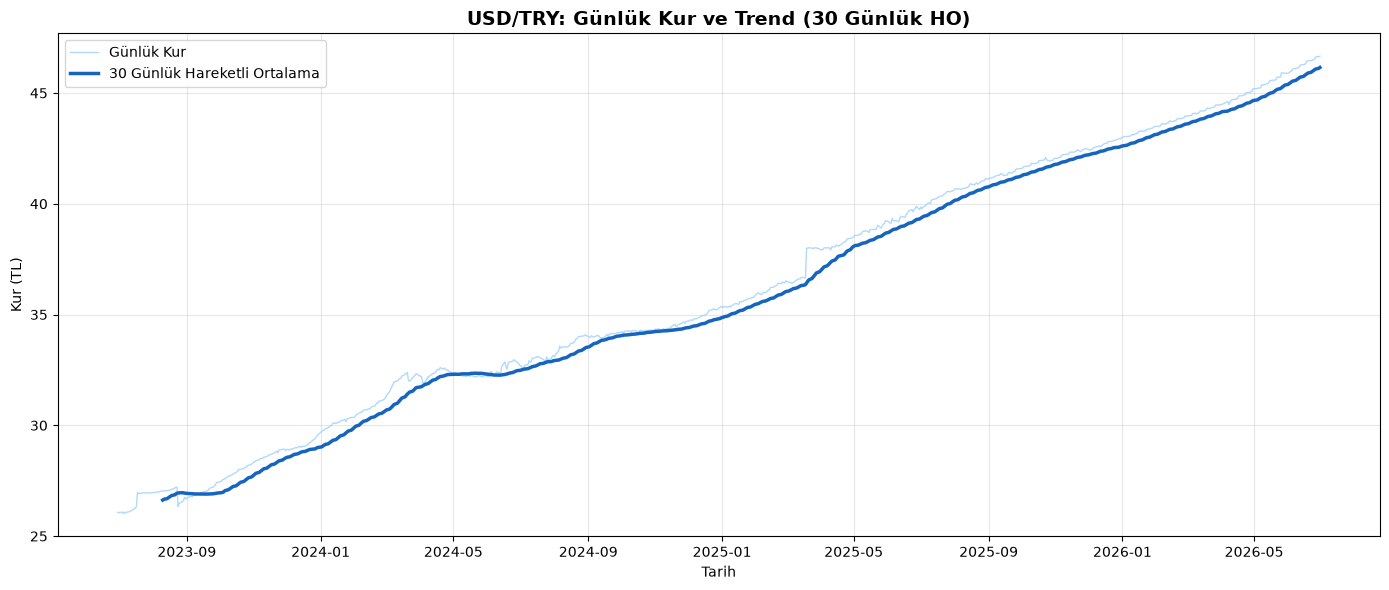

✅ Grafik kaydedildi!


In [8]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df["tarih"], df["USD_TRY"], label="Günlük Kur", color="#90CAF9", linewidth=1, alpha=0.7)
ax.plot(df["tarih"], df["USD_TRY_MA30"], label="30 Günlük Hareketli Ortalama", color="#1565C0", linewidth=2.5)

ax.set_title("USD/TRY: Günlük Kur ve Trend (30 Günlük HO)", fontsize=14, fontweight="bold")
ax.set_xlabel("Tarih")
ax.set_ylabel("Kur (TL)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/02_usd_try_hareketli_ortalama.png", dpi=150)
plt.show()
print("✅ Grafik kaydedildi!")

      ortalama_kur  min_kur  max_kur  volatilite
yil                                             
2023         27.65    26.02    29.55        0.39
2024         32.87    29.73    35.36        0.24
2025         39.57    35.32    42.96        0.26
2026         44.64    43.03    46.66        0.09


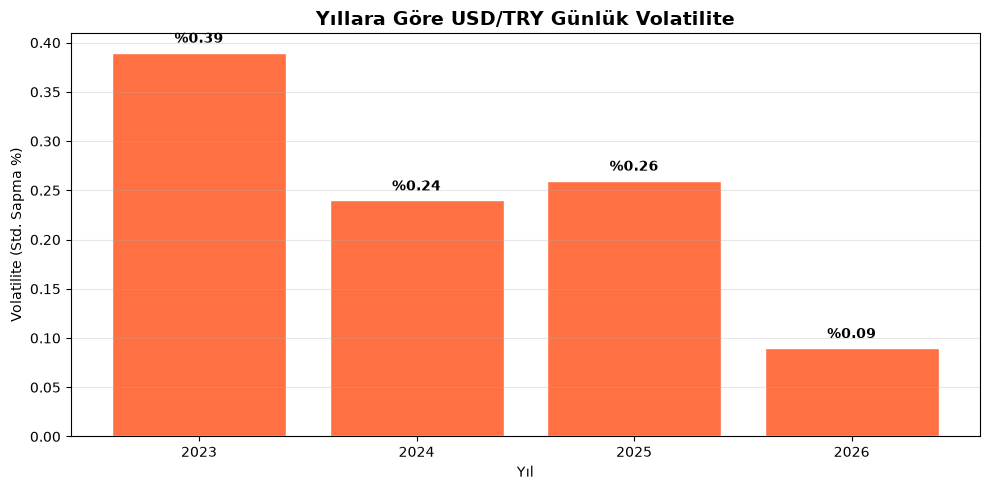

✅ Grafik kaydedildi!


In [9]:
df["yil"] = df["tarih"].dt.year

yillik_ozet = df.groupby("yil").agg(
    ortalama_kur=("USD_TRY", "mean"),
    min_kur=("USD_TRY", "min"),
    max_kur=("USD_TRY", "max"),
    volatilite=("USD_TRY_getiri", "std")
).round(2)

print(yillik_ozet)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(yillik_ozet.index.astype(str), yillik_ozet["volatilite"], color="#FF7043", edgecolor="white")

for bar, val in zip(bars, yillik_ozet["volatilite"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"%{val:.2f}", ha="center", fontweight="bold")

ax.set_title("Yıllara Göre USD/TRY Günlük Volatilite", fontsize=14, fontweight="bold")
ax.set_xlabel("Yıl")
ax.set_ylabel("Volatilite (Std. Sapma %)")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("../outputs/03_yillik_volatilite.png", dpi=150)
plt.show()
print("✅ Grafik kaydedildi!")